In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from common import banco
from common.config import MY_PALETTE, MY_COLORS

import warnings

warnings.filterwarnings("ignore", category=UserWarning)


def reais(valor):
    """Formata um número como moeda brasileira: 1234.5 -> 'R$ 1.234,50'."""
    texto = f"{valor:,.2f}"
    return "R$ " + texto.replace(",", "X").replace(".", ",").replace("X", ".")


def print_nulos_por_col(df):
    print("Nulos por coluna:")
    nulos = df.isnull().sum()
    pct = (nulos / len(df) * 100).round(1)
    for col in df.columns:
        if nulos[col] > 0:
            print(f"  {col}: {nulos[col]} ({pct[col]}%)")
    print()


def relatorio_df(df, descricao):
    # Criação do relatório de qualidade
    def relatorio_qualidade(df, nome):
        print(f"\n{'=' * 50}")
        print(f"RELATÓRIO: {nome}".center(50))
        print(f"{'=' * 50}")
        print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
        print()
        print_nulos_por_col(df)
        n_duplicatas = df.duplicated().sum()
        print(f"Duplicatas: {n_duplicatas} ({n_duplicatas / len(df) * 100:.2f}%)")
        print()
        print("Tipos das colunas:")
        print(df.dtypes)

    relatorio_qualidade(df, descricao)
    print()


Primeiro, é interessante saber o quão confiáveis estes dados são.
Para tanto, à seguir é realizada uma análise de qualidade dos dados presentes nas 4 tabelas da camada silver que já foram padronizados e tipados em etapa anterior (2_transformar.py).

In [3]:
try:
    conexao = banco.conectar()
    for tabela in ["silver_viagem", "silver_passagem", "silver_trecho", "silver_pagamento"]:
        q = pd.read_sql(f"select * from {tabela};", conexao)
        relatorio_df(q, f"Transparẽncia - {tabela}")
except BaseException as erro:
    print(f"Ocorreu a seguinte exceção: {erro}")
finally:
    conexao.close()


     RELATÓRIO: Transparẽncia - silver_viagem     
Linhas: 341860 | Colunas: 18

Nulos por coluna:
  cargo: 127931 (37.4%)
  motivo: 1 (0.0%)

Duplicatas: 0 (0.00%)

Tipos das colunas:
id_viagem               object
num_proposta            object
situacao                object
viagem_urgente          object
cod_orgao_superior      object
nome_orgao_superior     object
nome_viajante           object
cargo                   object
data_inicio             object
data_fim                object
destinos                object
motivo                  object
valor_diarias          float64
valor_passagens        float64
valor_devolucao        float64
valor_outros_gastos    float64
valor_total            float64
duracao_dias             int64
dtype: object


    RELATÓRIO: Transparẽncia - silver_passagem    
Linhas: 167260 | Colunas: 12

Nulos por coluna:
  uf_origem_ida: 5196 (3.1%)
  uf_destino_ida: 6243 (3.7%)
  data_emissao: 664 (0.4%)

Duplicatas: 0 (0.00%)

Tipos das colunas:
id_passagem 

Percebe-se que nenhuma das tabelas registraram valores duplicados. Adicionalmente, com a exceção da tabela silver_viagem (para o atributo 'cargo' com 37,4%), todas as outras possuem colunas com números insignificantes de valores nulos (no máximo de 3,7% em silver_passagem). Entende-se que, portanto, é possível sim fazer uso de todas as colunas (tomando o cuidado de desconsiderar o atributo 'cargo' de silver_viagem) sem prejuízo no resultado da análise.

Na sequência, as seguintes perguntas de negócio são respondidas:

- Os 5 órgãos com maior custo total?
- Os 3 destinos com maior custo médio por viagem?
- A viagem de maior duração e seu custo total?
- Qual o tipo de pagamento com maior valor médio?
- Qual o meio de transporte mais usado nos trechos?
- Qual UF de destino aparece em mais trechos?
- Qual órgão pagou mais no total?

Top 5 órgãos com maior custo total
                              nome_orgao_superior  custo_total   pct
0       Ministério Da Justiça E Segurança Pública 486933121.65 40.98
1                            Ministério Da Defesa 156070304.49 13.14
2                          Ministério Da Educação 111291349.34  9.37
3  Ministério Do Meio Ambiente E Mudança Do Clima  49697710.16  4.18
4                Ministério Da Previdência Social  40417309.06   3.4



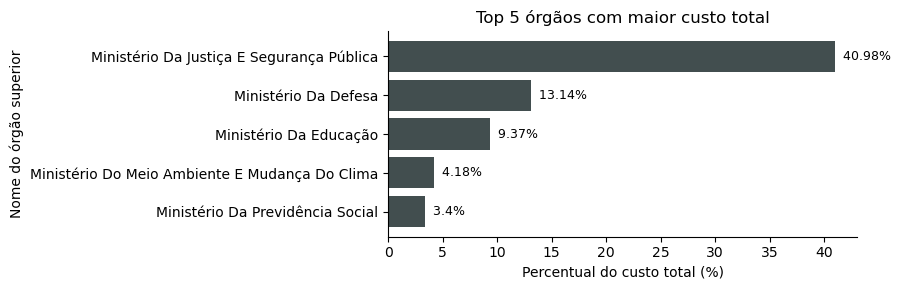

In [2]:
"Os 5 órgãos com maior custo total?"

try:
    conexao = banco.conectar()

    banco.executar(conexao, "DROP TABLE IF EXISTS gold_top_orgaos_custo_total;")
    banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_top_orgaos_custo_total;")

    banco.executar(
    conexao,
    """
    CREATE TABLE gold_top_orgaos_custo_total AS
    SELECT nome_orgao_superior, SUM(valor_total) as custo_total, ROUND(100 * SUM(valor_total) / (SELECT SUM(valor_total) FROM silver_viagem), 2) as pct
    FROM silver_viagem
    GROUP BY nome_orgao_superior;
    """
    )
    banco.executar(
    conexao,
    """
    CREATE VIEW vw_gold_top_orgaos_custo_total AS
    SELECT nome_orgao_superior, SUM(valor_total) as custo_total, ROUND(100 * SUM(valor_total) / (SELECT SUM(valor_total) FROM silver_viagem), 2) as pct
    FROM silver_viagem
    GROUP BY nome_orgao_superior;
    """
    )
    
    q1 = pd.read_sql("SELECT * FROM gold_top_orgaos_custo_total ORDER BY custo_total DESC LIMIT 5;", conexao)

    q1["nome_orgao_superior"] = q1["nome_orgao_superior"].str.title()
    print("Top 5 órgãos com maior custo total")
    print(q1.to_string(float_format=lambda f: str(f)))
    print()

    base_color = MY_COLORS["base"]
    fig, ax = plt.subplots(figsize=(9,3))
    ax.barh(q1["nome_orgao_superior"], q1["pct"], color=base_color)
    ax.invert_yaxis()  # maior em cima
    ax.set_title("Top 5 órgãos com maior custo total")
    ax.set_xlabel("Percentual do custo total (%)")
    ax.set_ylabel("Nome do órgão superior")
    for i, valor in enumerate(q1["pct"]):
        ax.text(valor, i, "  " + str(valor) + "%", va="center", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
except BaseException as erro:
    print(f"Ocorreu uma exceção: {erro}")
finally:
    conexao.close()

Percebe-se que o Ministério da Justiça e Segurança Pública foi responsável por aproximadamente 41% do custo total de viagens do dataset. Sendo uma diferença muito significativa em relação aos outros órgãos, que registraram os valores de 13%, 9%, 4% e 3% respectivamente.

Top 3 destinos com maior valor médio dentre as viagens:
-------
Índice: 0
Destinos: ABU DABI/EMIRADOS ÁRABES, RIAD/ARÁBIA SAUDITA, RIO DE JANEIRO/RJ
Valor médio: R$ 245.852,80
Quantidade de viagens com os mesmos destinos: 1
-------
Índice: 1
Destinos: BRASÍLIA/DF, RIO BRANCO/AC, CRUZEIRO DO SUL/AC, RIO BRANCO/AC, BRASÍLIA/DF, SÃO PAULO/SP, BRASÍLIA/DF, CUIABÁ/MT, BRASÍLIA/DF, TERESINA/PI, BRASÍLIA/DF, MACEIÓ/AL, BRASÍLIA/DF, RIO DE JANEIRO/RJ, BRASÍLIA/DF, PALMAS/TO, BRASÍLIA/DF, MANAUS/AM, BRASÍLIA/DF, CUIABÁ/MT, BRASÍLIA/DF, CAMPINAS/SP, BRASÍLIA/DF, BELO HORIZONTE/MG, PORTO ALEGRE/RS, BRASÍLIA/DF, FOZ DO IGUAÇU/PR, BRASÍLIA/DF, FORTALEZA/CE, BRASÍLIA/DF, BELÉM/PA, MANAUS/AM, BRASÍLIA/DF, CURITIBA/PR, FOZ DO IGUAÇU/PR, BRASÍLIA/DF, FORTALEZA/CE, BRASÍLIA/DF, SÃO PAULO/SP, BRASÍLIA/DF, SALVADOR/BA, BRASÍLIA/DF, RIO DE JANEIRO/RJ, BRASÍLIA/DF, NATAL/RN, JOÃO PESSOA/PB, BRASÍLIA/DF, BRASÍLIA/DF
Valor médio: R$ 216.729,36
Quantidade de viagens com os mesmos destinos: 1
-------
Índice: 2


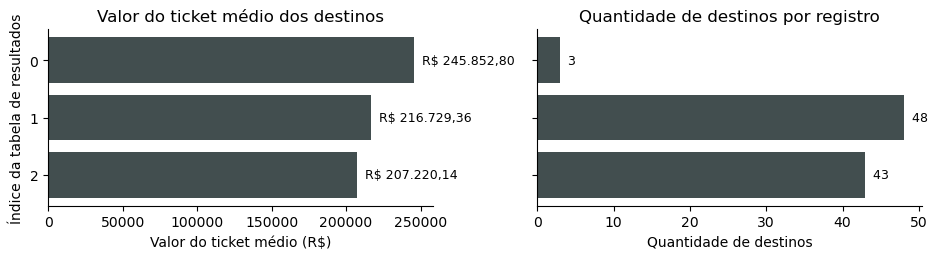

In [3]:
"Os 3 destinos com o maior custo médio por viagem?"

try:
    conexao = banco.conectar()
    
    banco.executar(conexao, "DROP TABLE IF EXISTS gold_3_destinos_com_maior_valor_medio;")
    banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_3_destinos_com_maior_valor_medio;")

    banco.executar(
    conexao,
    """
    CREATE TABLE gold_3_destinos_com_maior_valor_medio AS
    SELECT destinos, AVG(valor_total) as valor_medio, COUNT(*) as qtd
    FROM silver_viagem
    GROUP BY destinos;
    """
    )
    banco.executar(
    conexao,
    """
    CREATE VIEW vw_gold_3_destinos_com_maior_valor_medio AS
    SELECT destinos, AVG(valor_total) as valor_medio, COUNT(*) as qtd
    FROM silver_viagem
    GROUP BY destinos;
    """
    )
    
    q1 = pd.read_sql("SELECT * FROM gold_3_destinos_com_maior_valor_medio ORDER BY valor_medio DESC LIMIT 3;", conexao)
    print("Top 3 destinos com maior valor médio dentre as viagens:")
    for reg in q1.itertuples(index=True):
        print("-------")
        print(f"Índice: {reg.Index}")
        print(f"Destinos: {reg.destinos}")
        print(f"Valor médio: {reais(reg.valor_medio)}")
        print(f"Quantidade de viagens com os mesmos destinos: {reg.qtd}")
    print()

    base_color = MY_COLORS["base"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 2.7))
    indices = [str(i) for i in q1.index]
    ax1.barh(indices, q1["valor_medio"], color=base_color)
    ax1.invert_yaxis()  # maior em cima
    ax1.set_title("Valor do ticket médio dos destinos")
    ax1.set_xlabel("Valor do ticket médio (R$)")
    ax1.set_ylabel("Índice da tabela de resultados")
    for i, valor in enumerate(q1["valor_medio"]):
        ax1.text(valor, i, "  " + reais(valor), va="center", fontsize=9)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    qtd_destinos = [len(destinos) for destinos in q1["destinos"].str.split(", ")]
    ax2.barh(indices, qtd_destinos, color=base_color)
    ax2.invert_yaxis()  # maior em cima
    ax2.set_title("Quantidade de destinos por registro")
    ax2.set_xlabel("Quantidade de destinos")
    ax2.set_yticklabels([])
    for i, valor in enumerate(qtd_destinos):
        ax2.text(valor, i, "  " + str(valor), va="center", fontsize=9)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

except BaseException as erro:
    print(f"Ocorreu uma exceção: {erro}")
finally:
    conexao.close()

Nota-se que os 3 registros cujo destinos possuem o maior ticket médio pertencem à apenas uma viagem, cada um. Deve-se relembrar que uma viagem é composta por diversos trechos, com cada trecho composto por um local de 'origem' e um local de 'destino'. O campo 'destinos' dessa tabela concatena todos os destinos dos trechos de cada viagem. Para esses registros, seus valores de ticket resultaram maiores que R\\$ 200.000,00 até quase R\\$ 250.000,00. Já a quantidade de locais nos destinos varia de 3 até 48, com um valor médio de destinos visitados de 31,33.

Para se ter uma melhor compreensão do dataset e conseguir representar o comportamento geral da tabela de viagens, pode-se realizar um filtro na query para limpar possíveis distorções nos resultados de viagens muito mais caras que as demais e pouco frequentes. Esta nova query e seus resultados são demonstrados à seguir.

Top 3 destinos com maior valor médio dentre as viagens:
                                                          destinos  valor_medio  qtd
0               BRASÍLIA/DF, BRASÍLIA/DF, BRASÍLIA/DF, BRASÍLIA/DF    105470.37   91
1                            BRASÍLIA/DF, BRASÍLIA/DF, BRASÍLIA/DF    100317.26   88
2  BRASÍLIA/DF, BRASÍLIA/DF, BRASÍLIA/DF, BRASÍLIA/DF, BRASÍLIA/DF     97736.69   47



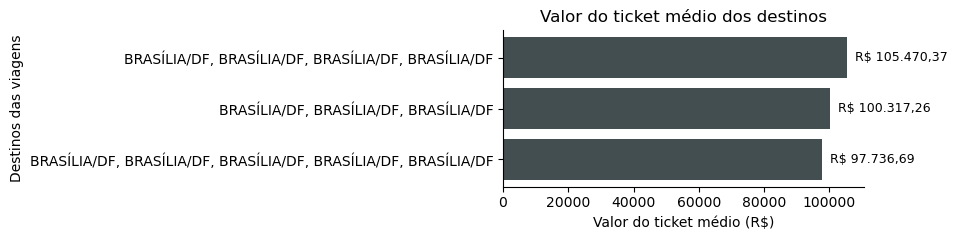

In [4]:
"Os 3 destinos com o maior custo médio por viagem?"

try:
    conexao = banco.conectar()
    
    banco.executar(conexao, "DROP TABLE IF EXISTS gold_3_destinos_com_maior_valor_medio_filt;")
    banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_3_destinos_com_maior_valor_medio_filt;")

    banco.executar(
    conexao,
    """
    CREATE TABLE gold_3_destinos_com_maior_valor_medio_filt AS
    SELECT destinos, ROUND(AVG(valor_total), 2) as valor_medio, COUNT(*) as qtd
    FROM silver_viagem
    WHERE destinos <> ''
    GROUP BY destinos
    HAVING qtd >= 30;
    """
    )
    banco.executar(
    conexao,
    """
    CREATE VIEW vw_gold_3_destinos_com_maior_valor_medio_filt AS
    SELECT destinos, ROUND(AVG(valor_total), 2) as valor_medio, COUNT(*) as qtd
    FROM silver_viagem
    WHERE destinos <> ''
    GROUP BY destinos
    HAVING qtd >= 30;
    """
    )
    
    q1 = pd.read_sql("SELECT * FROM gold_3_destinos_com_maior_valor_medio_filt ORDER BY valor_medio DESC LIMIT 3;", conexao)
    print("Top 3 destinos com maior valor médio dentre as viagens:")
    print(q1.to_string())
    print()

    base_color = MY_COLORS["base"]
    fig, ax1 = plt.subplots(figsize=(9.5, 2.5))
    ax1.barh(q1["destinos"], q1["valor_medio"], color=base_color)
    ax1.invert_yaxis()  # maior em cima
    ax1.set_title("Valor do ticket médio dos destinos")
    ax1.set_xlabel("Valor do ticket médio (R$)")
    ax1.set_ylabel("Destinos das viagens")
    for i, valor in enumerate(q1["valor_medio"]):
        ax1.text(valor, i, "  " + reais(valor), va="center", fontsize=9)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

except BaseException as erro:
    print(f"Ocorreu uma exceção: {erro}")
finally:
    conexao.close()

Ao se realizar a filtragem de viagens que ocorrem com pouca frequência, é possível se ter uma melhor compreensão do conjunto de dados. Nota-se que as viagens mais caras, em média, possuem exclusivamente o destino 'Brasília/DF' no seu atributo de 'destinos'. Indicando que a capital do país, por diversos motivos, age como um hub principal de conexão do conjunto de viagens analisado. Vale lembrar que a capital, além de ser o centro administrativo do governo federal, também está basicamente posicionada no centro geográfico, podendo atender de forma mais uniforme todo o território nacional.

Top 10 viagens de maior duração e seus respectivos custos totais:
             id_viagem                        nome_orgao_superior  duracao_dias  valor_total
0  0000000000020699856           Ministério Da Previdência Social           383         0.00
1  0000000000020793594  Ministério Da Justiça E Segurança Pública           378    120650.00
2  0000000000020793492  Ministério Da Justiça E Segurança Pública           369    113382.50
3  0000000000020774569                     Ministério Da Educação           369         0.00
4  0000000000020685666  Ministério Da Justiça E Segurança Pública           366    124312.50
5  0000000000020592696  Ministério Da Justiça E Segurança Pública           366    159044.90
6  0000000000020589962                     Ministério Da Educação           365         0.00
7  0000000000020732132                     Ministério Da Educação           365         0.00
8  0000000000020536724  Ministério Da Justiça E Segurança Pública           364    134208.77
9  0

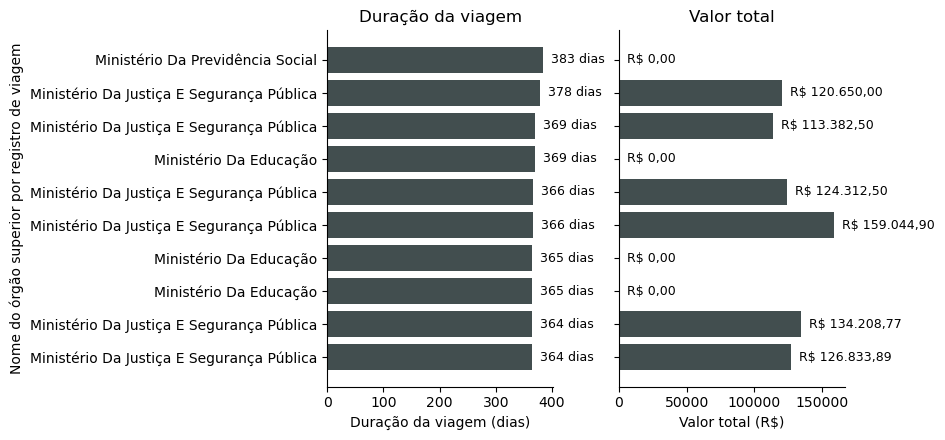

In [5]:
"A viagem de maior duração e seu custo total?"

try:
    conexao = banco.conectar()

    banco.executar(conexao, "DROP TABLE IF EXISTS gold_viagem_maior_duracao;")
    banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_viagem_maior_duracao;")
    
    banco.executar(
    conexao,
    """
    CREATE TABLE gold_viagem_maior_duracao AS
    SELECT id_viagem, nome_orgao_superior, duracao_dias, valor_total
    FROM silver_viagem
    ORDER BY duracao_dias DESC;
    """
    )
    banco.executar(
    conexao,
    """
    CREATE VIEW vw_gold_viagem_maior_duracao AS
    SELECT id_viagem, nome_orgao_superior, duracao_dias, valor_total
    FROM silver_viagem
    ORDER BY duracao_dias DESC;
    """
    )
    
    q1 = pd.read_sql("SELECT * FROM vw_gold_viagem_maior_duracao LIMIT 10;", conexao)
    q1["nome_orgao_superior"] = q1["nome_orgao_superior"].str.title()

    print("Top 10 viagens de maior duração e seus respectivos custos totais:")
    print(q1.to_string())
    print()

    base_color = MY_COLORS["base"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.5))
    ax1.barh(q1["id_viagem"], q1["duracao_dias"], color=base_color)
    ax1.invert_yaxis()  # maior em cima
    ax1.set_title("Duração da viagem")
    ax1.set_xlabel("Duração da viagem (dias)")
    ax1.set_ylabel("Nome do órgão superior por registro de viagem")
    for i, valor in enumerate(q1["duracao_dias"]):
        ax1.text(valor, i, "  " + str(valor) + " dias", va="center", fontsize=9)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.set_yticklabels(q1["nome_orgao_superior"])
    
    ax2.barh(q1["id_viagem"], q1["valor_total"], color=base_color)
    ax2.invert_yaxis()  # maior em cima
    ax2.set_title("Valor total")
    ax2.set_xlabel("Valor total (R$)")
    ax2.set_yticklabels([])
    for i, valor in enumerate(q1["valor_total"]):
        ax2.text(valor, i, "  " + reais(valor), va="center", fontsize=9)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

except BaseException as erro:
    print(f"Ocorreu uma exceção: {erro}")
finally:
    conexao.close()

O custo total da viagem que possui a maior duração (383 dias) é de R\\$ 0,00. Realizando uma melhor inspeção dos registros das 10 viagens mais longas em duração, é possível perceber que as únicas viagens que possuem custo são referentes ao Ministério da Justiça e Segurança Pública. Todas as outras instituições (Ministério da Previdência Social e Ministério da Educação) registraram custo nulo. Verificando as respectivas motivações, nota-se que é basicamente ou transferência de local de atuação de servidor público, ou afastamento de servidor para que este possa realizar treinamento/aperfeiçoamento no período.

Valores de ticket médio por tipo de pagamento:
              tipo_pagamento  valor_medio
0                    Diárias      2078.28
1                   Passagem      1878.34
2  Serviço Correlato: Seguro       447.51
3                Restituição       245.70



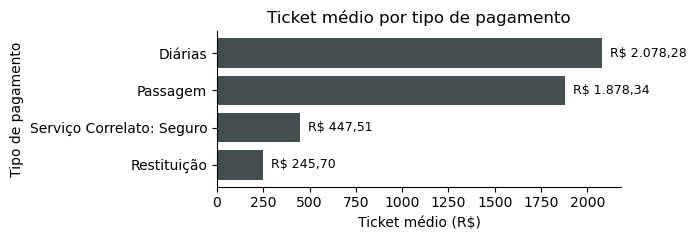

In [6]:
"Qual o tipo de pagamento com maior valor médio?"

try:
    conexao = banco.conectar()

    banco.executar(conexao, "DROP TABLE IF EXISTS gold_tipo_pagamento_por_ticket_medio;")
    banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_tipo_pagamento_por_ticket_medio;")

    banco.executar(
    conexao,
    """
    CREATE TABLE gold_tipo_pagamento_por_ticket_medio AS
    SELECT tipo_pagamento, ROUND(AVG(valor), 2) as valor_medio
    FROM silver_pagamento
    GROUP BY tipo_pagamento;
    """
    )
    banco.executar(
    conexao,
    """
    CREATE VIEW vw_gold_tipo_pagamento_por_ticket_medio AS
    SELECT tipo_pagamento, ROUND(AVG(valor), 2) as valor_medio
    FROM silver_pagamento
    GROUP BY tipo_pagamento;
    """
    )
    
    q1 = pd.read_sql("SELECT * FROM gold_tipo_pagamento_por_ticket_medio ORDER BY valor_medio DESC;", conexao)
    
    q1["tipo_pagamento"] = q1["tipo_pagamento"].str.title()
    print("Valores de ticket médio por tipo de pagamento:")
    print(q1)
    print()

    base_color = MY_COLORS["base"]
    fig, ax = plt.subplots(figsize=(7,2.5))
    ax.barh(q1["tipo_pagamento"], q1["valor_medio"], color=base_color)
    ax.invert_yaxis()  # maior em cima
    ax.set_title("Ticket médio por tipo de pagamento")
    ax.set_xlabel("Ticket médio (R$)")
    ax.set_ylabel("Tipo de pagamento")
    for i, valor in enumerate(q1["valor_medio"]):
        ax.text(valor, i, "  " + reais(valor), va="center", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

except BaseException as erro:
    print(f"Ocorreu uma exceção: {erro}")
finally:
    conexao.close()

Pela figura apresentada, percebe-se que, basicamente, os tipos de pagamento com os maiores valores de ticket médio são 'diárias' e 'passagem'. Respectivamente, os seus valores de ticket médio são R\\$ 2.078,28 e R\\$ 1.878,34. Já para os pagamentos dos tipos 'seguro' e 'restituição' os respectivos valores são de R\\$ 447,51 e R$ 245,70. Desta forma, é possível notar a presença de dois grupos de tipos significativamente distintos entre si.

Percentual dos meios de transporte utilizados
   meio_transporte     qtd    pct
0  Veículo Oficial  386424  50.62
1            Aéreo  232666  30.48
2       Rodoviário   64970   8.51
3  Veículo Próprio   42846   5.61
4         Inválido   26659   3.49
5          Fluvial    8429   1.10
6      Ferroviário     874   0.11
7         Marítimo     481   0.06



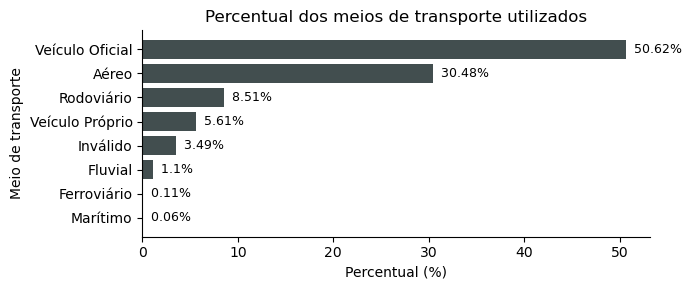

In [7]:
"Qual o meio de transporte mais usado nos trechos?"

try:
    conexao = banco.conectar()
    
    banco.executar(conexao, "DROP TABLE IF EXISTS gold_meio_transporte_mais_utilizado;")
    banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_meio_transporte_mais_utilizado;")

    banco.executar(
    conexao,
    """
    CREATE TABLE gold_meio_transporte_mais_utilizado AS
    SELECT meio_transporte, COUNT(*) as qtd, ROUND(100 * COUNT(*) / (SELECT COUNT(*) FROM silver_trecho), 2) as pct
    FROM silver_trecho
    GROUP BY meio_transporte;
    """
    )
    banco.executar(
    conexao,
    """
    CREATE VIEW vw_gold_meio_transporte_mais_utilizado AS
    SELECT meio_transporte, COUNT(*) as qtd, ROUND(100 * COUNT(*) / (SELECT COUNT(*) FROM silver_trecho), 2) as pct
    FROM silver_trecho
    GROUP BY meio_transporte;
    """
    )
    
    q1 = pd.read_sql("SELECT * FROM gold_meio_transporte_mais_utilizado ORDER BY qtd DESC;", conexao)
    
    q1["meio_transporte"] = q1["meio_transporte"].str.title()
    print("Percentual dos meios de transporte utilizados")
    print(q1)
    print()
    
    base_color = MY_COLORS["base"]
    fig, ax = plt.subplots(figsize=(7,3))
    ax.barh(q1["meio_transporte"], q1["pct"], color=base_color)
    ax.invert_yaxis()  # maior em cima
    ax.set_title("Percentual dos meios de transporte utilizados")
    ax.set_xlabel("Percentual (%)")
    ax.set_ylabel("Meio de transporte")
    for i, valor in enumerate(q1["pct"]):
        ax.text(valor, i, "  " + str(valor) + "%", va="center", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
    
except BaseException as erro:
    print(f"Ocorreu uma exceção: {erro}")
finally:
    conexao.close()

Nota-se que no dataset de viagens o meio de transporte amplamente mais empregado foi o 'veículo oficial', com representação superior à 50%. O segundo meio de transporte mais utilizado foi o 'aéreo' com uma participação de 30.5%. Na sequência, vêm os outros modais com percetuais significantemente inferiores, todos menores que 10%. Desta forma, mais de 80% de todas as viagens registradas fizeram uso de 'veículo oficial' ou 'aéreo'.

Top 10 UFs de destino que mais aparecem nos trechos
           destino_uf    qtd    pct
0           São Paulo  82722  10.84
1    Distrito Federal  79962  10.48
2        Minas Gerais  50965   6.68
3      Rio De Janeiro  44197   5.79
4              Paraná  42603   5.58
5                Pará  40044   5.25
6   Rio Grande Do Sul  38684   5.07
7  Mato Grosso Do Sul  30516   4.00
8               Bahia  28375   3.72
9          Pernambuco  28372   3.72



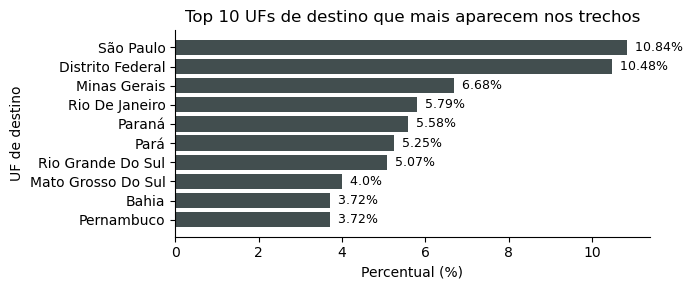

In [8]:
"Qual UF de destino aparece em mais trechos?"

try:
    conexao = banco.conectar()
    
    banco.executar(conexao, "DROP TABLE IF EXISTS gold_uf_destino_mais_frequente;")
    banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_uf_destino_mais_frequente;")

    banco.executar(
    conexao,
    """
    CREATE TABLE gold_uf_destino_mais_frequente AS
    SELECT destino_uf, COUNT(*) as qtd, ROUND(100 * COUNT(*) / (SELECT COUNT(*) FROM silver_trecho), 2) as pct
    FROM silver_trecho
    GROUP BY destino_uf;
    """
    )
    banco.executar(
    conexao,
    """
    CREATE VIEW vw_gold_uf_destino_mais_frequente AS
    SELECT destino_uf, COUNT(*) as qtd, ROUND(100 * COUNT(*) / (SELECT COUNT(*) FROM silver_trecho), 2) as pct
    FROM silver_trecho
    GROUP BY destino_uf;
    """
    )
    
    q1 = pd.read_sql("SELECT * FROM vw_gold_uf_destino_mais_frequente ORDER BY qtd DESC LIMIT 10;", conexao)
    
    q1["destino_uf"] = q1["destino_uf"].str.title()
    print("Top 10 UFs de destino que mais aparecem nos trechos")
    print(q1)
    print()

    base_color = MY_COLORS["base"]
    fig, ax = plt.subplots(figsize=(7,3))
    ax.barh(q1["destino_uf"], q1["pct"], color=base_color)
    ax.invert_yaxis()  # maior em cima
    ax.set_title("Top 10 UFs de destino que mais aparecem nos trechos")
    ax.set_xlabel("Percentual (%)")
    ax.set_ylabel("UF de destino")
    for i, valor in enumerate(q1["pct"]):
        ax.text(valor, i, "  " + str(valor) + "%", va="center", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
    
except BaseException as erro:
    print(f"Ocorreu uma exceção: {erro}")
finally:
    conexao.close()

Das 10 unidades federativas (UF) mais frequentes nos trechos, pode-se citar 'São Paulo' e 'Distrito Federal' com participação de 10,84% e 10,48% respectivamente. Na sequência, as outras UFs registraram valores de participação gradualmente menores que 7%. Pode-se entender que os dois destinos mais frequentes constituem um grupo particular por si só.

Top 10 órgãos que mais pagaram no total
                                                         nome_orgao_pagador        total   pct
0                                       Fundo Nacional De Segurança Pública 278481047.89 23.32
1                                                                  Sigiloso 200484801.68 16.79
2                                                    Comando Da Aeronáutica  81769144.77  6.85
3                                       Instituto Nacional Do Seguro Social  37427601.45  3.13
4                                                       Comando Do Exército  36872643.95  3.09
5                   Ministério Da Gestão E Da Inovação Em Serviços Públicos  35541760.71  2.98
6  Instituto Brasileiro Do Meio Ambiente E Dos Recursos Naturais Renováveis  31589853.15  2.64
7                                        Ministério Das Relações Exteriores  25605376.38  2.14
8                                                 Receita Federal Do Brasil   23811027.0  1.99
9         

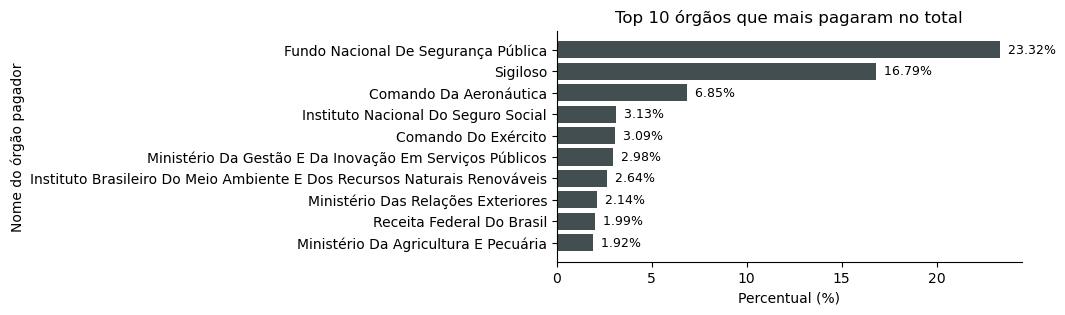

In [9]:
"Qual órgão pagou mais no total?"

try:
    conexao = banco.conectar()

    banco.executar(conexao, "DROP TABLE IF EXISTS gold_orgao_pagou_mais;")
    banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_orgao_pagou_mais;")
    
    banco.executar(
    conexao,
    """
    CREATE TABLE gold_orgao_pagou_mais AS
    SELECT nome_orgao_pagador, SUM(valor) as total, ROUND(100 * SUM(valor) / (SELECT SUM(valor) FROM silver_pagamento), 2) as pct
    FROM silver_pagamento
    GROUP BY nome_orgao_pagador;
    """
    )
    banco.executar(
    conexao,
    """
    CREATE VIEW vw_gold_orgao_pagou_mais AS
    SELECT nome_orgao_pagador, SUM(valor) as total, ROUND(100 * SUM(valor) / (SELECT SUM(valor) FROM silver_pagamento), 2) as pct
    FROM silver_pagamento
    GROUP BY nome_orgao_pagador;
    """
    )
    
    q1 = pd.read_sql("SELECT * FROM vw_gold_orgao_pagou_mais ORDER BY total DESC LIMIT 10;", conexao)
    
    q1["nome_orgao_pagador"] = q1["nome_orgao_pagador"].str.title()
    q1["nome_orgao_pagador"] = q1["nome_orgao_pagador"].str.replace(" - Unidades Com Vínculo Direto", "")
    print("Top 10 órgãos que mais pagaram no total")
    print(q1.to_string(float_format=str))
    print()

    base_color = MY_COLORS["base"]
    fig, ax = plt.subplots(figsize=(6,3))
    ax.barh(q1["nome_orgao_pagador"], q1["pct"], color=base_color)
    ax.invert_yaxis()  # maior em cima
    ax.set_title("Top 10 órgãos que mais pagaram no total")
    ax.set_xlabel("Percentual (%)")
    ax.set_ylabel("Nome do órgão pagador")
    for i, valor in enumerate(q1["pct"]):
        ax.text(valor, i, "  " + str(valor) + "%", va="center", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
    
except BaseException as erro:
    print(f"Ocorreu uma exceção: {erro}")
finally:
    conexao.close()

Da análise dos 10 órgãos que mais pagaram no total, é possível entender que o 'Fundo Nacional de Segurança Pública' lidera o ranking de pagamento, seguido pela categoria 'Sigiloso', 'Comando da Aeronáutica' e demais. Os 3 órgãos que mais pagaram totalizaram um percentual de 47% do total, enquanto que as demais categorias registraram valores abaixo de 3% cada.